## IN3050/IN4050 Mandatory Assignment 2, 2025: Supervised Learning

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html 
We do not entirely prohibit the use of generative language models ("smart assistants" like ChatGPT, Llama, Claude or Copilot), but you must clearly acknowledge this at all times, following the UiO guidelines: https://www.uio.no/english/studies/resources/ai_student.html
Note also that you must fully understand _all_ the parts of you submissions, even if you got some help from a generative model. This will be tested during your peer review sessions (https://www.uio.no/studier/emner/matnat/ifi/IN3050/v25/Peer%20review/).
By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, March 28, 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a regular Python script if you prefer.

#### Alternative 1
If you prefer not to use notebooks, you should deliver the code, your run results, and a PDF report where you answer all the questions and explain your work.

#### Alternative 2
If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a PDF of your solution which shows the results of the runs. (If you can't export: notebook -> latex -> pdf on your own machine, you may do this on the IFI linux machines.)

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must be runnable. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a PDF of the code, outputs, comments and plots as explained above.

Your report/notebook should contain your name and username.

Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
The goal of this assignment is to get a better understanding of supervised learning with gradient descent. It will, in particular, consider the similarities and differences between linear classifiers and multi-layer feed forward neural networks (multi-layer perceptrons, MLP) and the differences and similarities between binary and multi-class classification. 

### Tools
The aim of the exercises is to give you a look inside the learning algorithms. You may freely use code from the weekly exercises and the published solutions. You should not use machine learning libraries like Scikit-Learn or PyTorch, because the point of this assignment is for you to implement things from scratch. You, however, are encouraged to use tools like NumPy, Pandas and MatPlotLib, which are not ML-specific.

The given precode uses NumPy. You are recommended to use NumPy since it results in more compact code, but feel free to use pure Python if you prefer. 

If anything is unclear, do not hesitate to ask. Also, if you think some assumptions are missing, make your own and explain them!

### Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn # This is only to generate a dataset

## Datasets

We start by making a synthetic dataset of 5000 instances and ten classes, with 500 instances in each class. (See https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html regarding how the data are generated.) We choose to use a synthetic dataset---and not a set of natural occuring data---because we are mostly interested in properties of the various learning algorithms, in particular the differences between linear classifiers and multi-layer neural networks together with the difference between binary and multi-class data. In addition, we would like a dataset with instances represented with only two numerical features, so that it is easy to visualize the data. It would be rather difficult (although not impossible) to find a real-world dataset of the same nature. Anyway, you surely can use the code in this assignment for training machine learning models on real-world datasets.

When we are doing experiments in supervised learning, and the data are not already split into training and test sets, we should start by splitting the data. Sometimes there are natural ways to split the data, say training, on data from one year and testing on data from a later year, but if that is not the case, we should shuffle the data randomly before splitting. (OK, that is not necessary with this particular synthetic data set, since it is already shuffled by default by Scikit-Learn, but that will not be the case with real-world data) We should split the data so that we keep the alignment between X (features) and t (class labels), which may be achieved by shuffling the indices. We split into 60% for training, 20% for validation, and 20% for final testing. The set for final testing *must not be used* till the end of the assignment in part 3.

We fix the seed both for data set generation and for shuffling, so that we work on the same datasets when we rerun the experiments. This is done by the `random_state` argument and the `rng = np.random.RandomState(424242)`.

In [2]:
# Generating the dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[500, 500, 500, 500, 500, 500, 500, 500, 500, 500], centers=[[0,1],[4,2],[8,1],[2,0],[6,0],[3,-3],[4,-2],[0,5],[0,4],[-2,-2]], 
                  n_features=2, random_state=424242, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5, 3.0, 1.0, 0.5, 2.5, 2.5])

In [3]:
# Shuffling the dataset
indices = np.arange(X.shape[0])
rng = np.random.RandomState(424242)
rng.shuffle(indices)
indices[:10]

array([3560, 4674,   49, 1257,  661, 3066, 3834, 4792,  570, 3855])

In [4]:
# Splitting into train, dev and test
X_train = X[indices[:3000],:]
X_val = X[indices[3000:4000],:]
X_test = X[indices[4000:],:]
t_multi_train = t_multi[indices[:3000]]
t_multi_val = t_multi[indices[3000:4000]]
t_multi_test = t_multi[indices[4000:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0-5` become the new `0` and `6-9` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [5]:
t2_train = t_multi_train >= 6
t2_train = t2_train.astype("int")
t2_val = (t_multi_val >= 6).astype("int")
t2_test = (t_multi_test >= 6).astype("int")

We can plot the two traning sets.

Text(0.5, 1.0, 'Multi-class set')

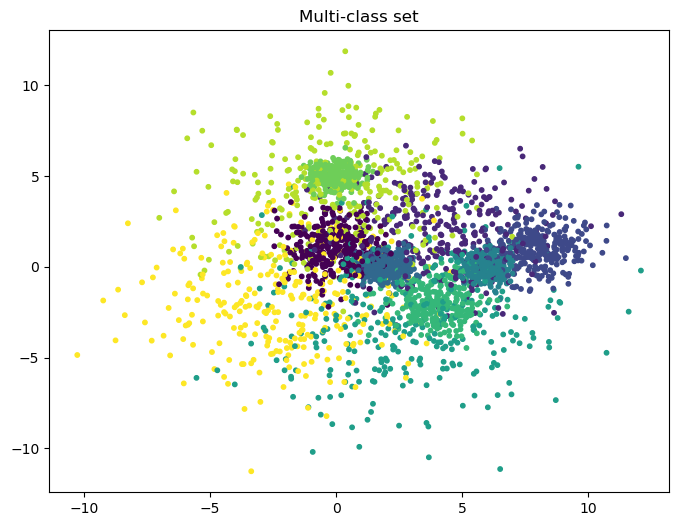

In [6]:
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

Text(0.5, 1.0, 'Binary set')

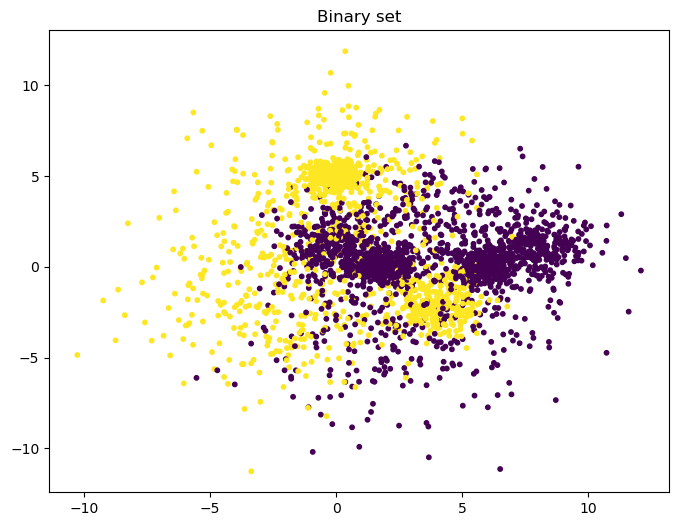

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
plt.title("Binary set")

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. You may make your own implementation from scratch or start with the solution to the weekly exercise set 6. We include it here with a little added flexibility.

In [8]:
def add_bias(X, bias):
    """X is a NxM matrix: N datapoints, M features
    bias is a bias term, -1 or 1, or any other scalar. Use 0 for no bias
    Return a Nx(M+1) matrix with added bias in position zero
    """
    N = X.shape[0]
    biases = np.ones((N, 1)) * bias # Make a N*1 matrix of biases
    # Concatenate the column of biases in front of the columns of X.
    return np.concatenate((biases, X), axis  = 1) 

In [9]:
class NumpyClassifier():
    """Common methods to all Numpy classifiers --- if any"""

In [10]:
class NumpyLinRegClass(NumpyClassifier):

    def __init__(self, bias=-1):
        self.bias=bias
    
    def fit(self, X_train, t_train, lr = 0.1, epochs=10):
        """X_train is a NxM matrix, N data points, M features
        t_train is avector of length N,
        the target class values for the training data
        lr is our learning rate
        """
        
        if self.bias:
            X_train = add_bias(X_train, self.bias)
            
        (N, M) = X_train.shape
        
        self.weights = weights = np.zeros(M)
        
        for epoch in range(epochs):
            # print("Epoch", epoch)
            weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)      
    
    def predict(self, X, threshold=0.5):
        """X is a KxM matrix for some K>=1
        predict the value for each point in X"""
        if self.bias:
            X = add_bias(X, self.bias)
        ys = X @ self.weights
        return ys > threshold

We can train and test a first classifier (on the binary dataset).

In [11]:
def accuracy(predicted, gold):
    return np.mean(predicted == gold)

In [12]:
cl = NumpyLinRegClass()
cl.fit(X_train, t2_train, epochs=10)
accuracy(cl.predict(X_val), t2_val)

0.638

The following is a small procedure which plots the data set together with the decision boundaries. 
You may modify the colors and the rest of the graphics as you like.
The procedure will also work for multi-class classifiers

In [13]:
def plot_decision_regions(X, t, clf=[], size=(8,6)):
    """Plot the data set (X,t) together with the decision boundary of the classifier clf"""
    # The region of the plane to consider determined by X
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Make a prediction of the whole region
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Classify each meshpoint.
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size) # You may adjust this

    # Put the result into a color plot
    plt.contourf(xx, yy, Z, alpha=0.2, cmap = 'tab10')

    plt.scatter(X[:,0], X[:,1], c=t, s=10.0, cmap='tab10')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision regions")
    plt.xlabel("x0")
    plt.ylabel("x1")

#    plt.show()

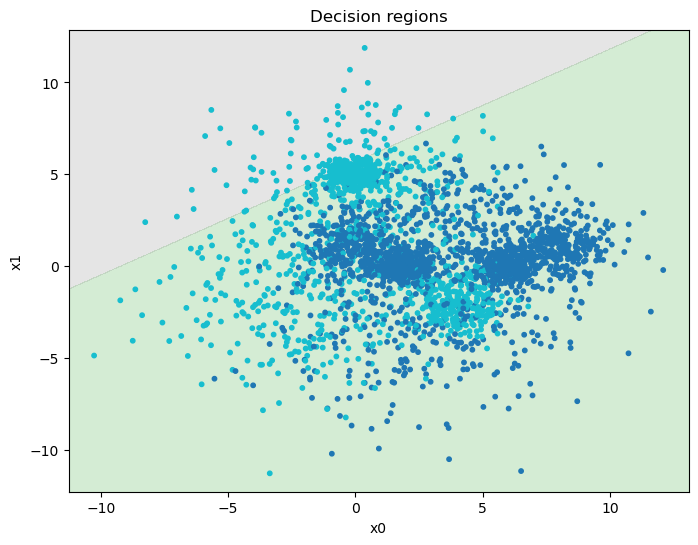

In [14]:
plot_decision_regions(X_train, t2_train, cl)

### Task: Tuning

The result is far from impressive. 
Remember that a classifier which always chooses the majority class will have an accuracy of 0.6 on this data set.

Your task is to try various settings for the two training hyper-parameters, learning rate and the number of epochs, to get the best accuracy on the validation set. 

Report how the accuracy varies with the hyper-parameter settings. It it not sufficient to give the final hyperparameters. You must also show how you found then and results for alternative values you tried aout.

When you are satisfied with the result, you may plot the decision boundaries, as above.

calculating learning rates :  0.001  to  0.101
calculating learning rates :  0.1  to  0.2


/tmp/ipykernel_521/1812362137.py:22: RuntimeWarning: overflow encountered in matmul
  weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)
/tmp/ipykernel_521/1812362137.py:22: RuntimeWarning: invalid value encountered in matmul
  weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)


calculating learning rates :  0.2  to  0.30000000000000004


/tmp/ipykernel_521/1812362137.py:29: RuntimeWarning: overflow encountered in matmul
  ys = X @ self.weights


Best Learning Rate: 0.051, Best Epochs: 50, Best Accuracy: 0.774
0.774
elapsed time:  9.560013055801392


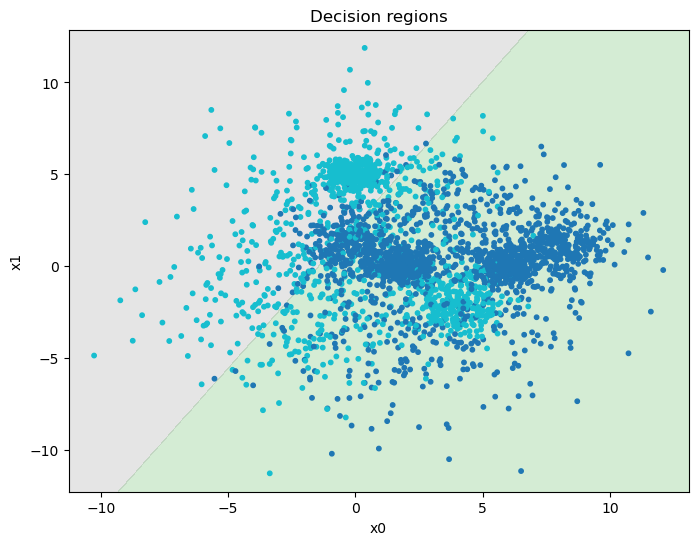

In [15]:
# the next question wants to compare the time therefore I add a way to measure time here:
import time
start_time = time.time()

# # First i tried to just put random learning rates and epochs inside the parameters
# regClass = NumpyLinRegClass()
# regClass.fit(X_train, t2_train, lr=0.55, epochs=100)
# accuracy(regClass.predict(X_val), t2_val)

# tried learning rate=0.5 and epochs=20
# prediction accuracy= 0.673

# tried learning rate=0.05 and epochs=100
# prediction accuracy= 0.762

# tried learning rate=0.055 and epochs=100
# prediction accuracy= 0.77

# Second I tried running a for loop between 0.1:0.9:0.1
# this was not very succesfull because the learning rate kept being 0.673 after the initial
# 
#for i in range(1,10):
#    regClass = NumpyLinRegClass()
#    print("learning rate: ", i / 100)
#    regClass.fit(X_train, t2_train, lr=float(i/10), epochs=50)
#    print(accuracy(regClass.predict(X_val), t2_val))

# My third attempt is to define a list of learning rates and a list of epochs and then loop over them

# Define hyperparameter ranges
learning_rates = [0.001, 0.1, 0.2]
epochs_list = [10, 50, 100, 500, 1000]

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, X_train, t2_train, X_val, t2_val):
    results = {}
    
    for lr in learning_rates:
        print("calculating learning rates : ", lr, " to ", lr + 0.1)
        for epochs in epochs_list:
            for i in range(0,100):
                i = i / 1000
                #print(lr, i, float(lr + i)) # debugging prints out the learning rate after applying a small step
                lr_temp = round(lr+i, 5)
                clf = NumpyLinRegClass()
                clf.fit(X_train, t2_train, lr=lr_temp, epochs=epochs)
                acc = accuracy(clf.predict(X_val), t2_val)
                results[(lr_temp, epochs)] = acc
    
    return results


results = evaluate_hyperparameters(learning_rates, epochs_list, X_train, t2_train, X_val, t2_val)

# Find best hyperparameters
best_params = max(results, key=results.get)
best_lr, best_epochs = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Accuracy: {results[best_params]:.3f}")

# now I just put the best learning rate and epochs into the function to validate the data and make a plot
regClass = NumpyLinRegClass()
regClass.fit(X_train, t2_train, lr=best_lr, epochs=best_epochs)
print(accuracy(regClass.predict(X_val), t2_val))

# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_regions(X_train, t2_train, regClass)


### Task: Scaling

We have seen in the lectures that scaling the data may improve training speed and sometimes the performance. 

- Implement the standard scaler (normalizer); you can also try other scaling techniques
- Scale the data
- Train the model on the scaled data
- Experiment with hyper-parameter settings and see whether you can speed  up or improve the training.
- Report final hyper-parameter settings and show how you found them.

calculating learning rates :  0.001  to  0.101
calculating learning rates :  0.1  to  0.2
calculating learning rates :  0.2  to  0.30000000000000004
Best Learning Rate: 0.051, Best Epochs: 50, Best Accuracy: 0.774
0.762
elapsed time:  9.687050104141235


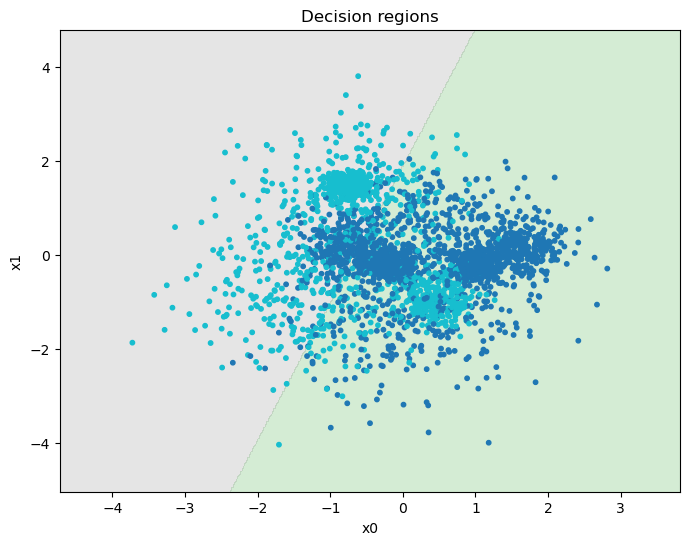

In [16]:
#from sklearn.preprocessing import StandardScaler, there is a standard scaler in the library but I assume that they want us to build our own
import time

start_time = time.time()

# Manual feature scaling (Standardization)
def standardize_data(X, mean=None, std=None):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Prevent division by zero
    return (X - mean) / std, mean, std

# Scale the data
X_train_scaled, mean, std = standardize_data(X_train)
X_val_scaled, _, _ = standardize_data(X_val, mean, std)

results_scaled = evaluate_hyperparameters(learning_rates, epochs_list, X_train_scaled, t2_train, X_val_scaled, t2_val)

# Find best hyperparameters
best_params = max(results_scaled, key=results.get)
best_lr, best_epochs = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Accuracy: {results[best_params]:.3f}")

# now I just put the best learning rate and epochs into the function to validate the data and make a plot
regClassScaled = NumpyLinRegClass()
regClassScaled.fit(X_train_scaled, t2_train, lr=best_lr, epochs=best_epochs)
print(accuracy(regClassScaled.predict(X_val_scaled), t2_val))

# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_regions(X_train_scaled, t2_train, regClassScaled)

linear_reg = regClassScaled # this is for the final part 3 where you need to evaluate all the models

# it doesn't seem to me that the training time changes substantially
# the accuracy also does not go up, I mainly believe that this is due to the training data being very non-linearly spereable, meaning that this standard linear model cannot really do a good job of seperating the data, which leads to this lower accuracy
# it could also depend on the scaling function


## Logistic regression
a) You should now implement a logistic regression classifier similarly to the classifier based on linear regression.
You may use the code from the solution to weekly exercise set week06.

b) In addition to the method `predict()` which predicts a class for the data, include a method `predict_probabilities()` which predicts the probability of the data belonging to the positive class.

c) So far, we have not calculated the loss explicitly in the code. Extend the code to calculate the loss on the training set for each epoch and to store the losses such that the losses can be inspected after training. The prefered loss for logistic regression is binary cross-entropy, but you can also try mean squared error. The most important is that your implementation of the loss corresponds to your implementation of the gradient descent.
Also, calculate and store accuracies after each epoch.

d) In addition, extend the `fit()` method with optional arguments for a validation set (X_val, t_val). If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch. 

e) The training runs for a number of epochs. We cannot know beforehand for how many epochs it is reasonable to run the training. One possibility is to run the training until the learning does not improve much. Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved with more than `tol` after `n_epochs_no_update` (to save compute and potentially avoid over-fitting). A possible default value for `n_epochs_no_update` is 2. Also, add an attribute to the classifier which tells us after fitting how many epochs it was trained for.

f) Train classifiers with various learning rates, and with varying values for `tol` for finding the optimal values. Also consider the effect of scaling the data.

g) After a succesful training, for your best model, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see. Are the curves monotone? Is this as expected?

calculating learning rates :  0.001  to  0.101
calculating learning rates :  0.1  to  0.2
calculating learning rates :  0.2  to  0.3
Best Learning Rate: 0.052, Best Epochs: 185, Best Tolerance: 0.0001, Best n_epochs_no_update: 2, Best Accuracy: 0.753
best model accuracy:  0.753
elapsed time:  76.83877801895142


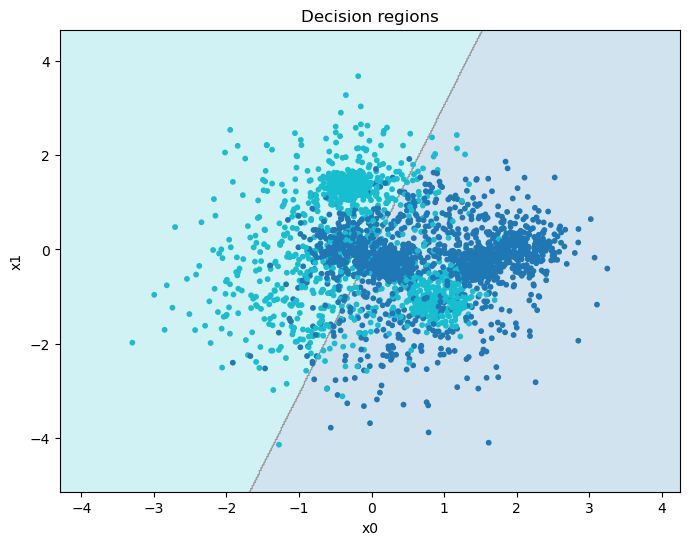

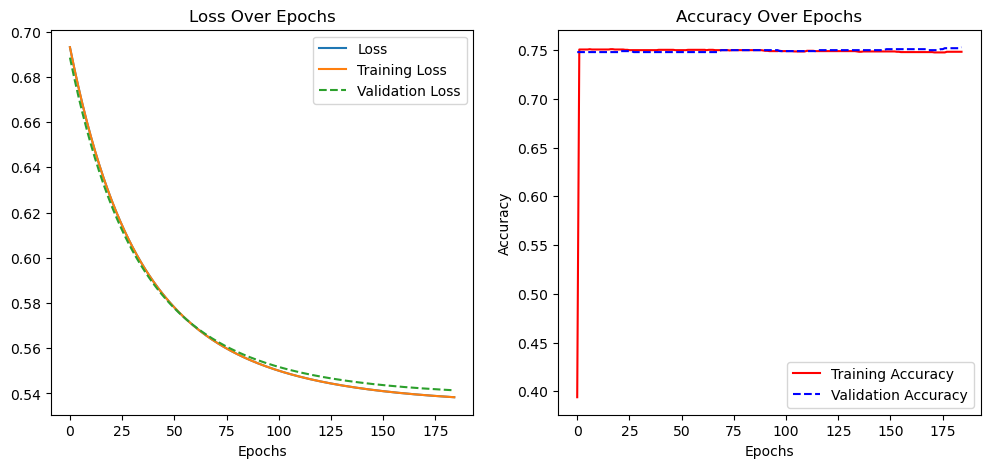

In [17]:
# a)
start_time = time.time()

# Define Logistic Regression Classifier
class LogisticRegression:
    # task E: add auto count epochs and stop epochs when the loss has not improved with more than tol after n_epochs_no_update
    def __init__(self, tol=1e-4, n_epochs_no_update=2):
        self.weights = None
        # task c: calculating loss
        self.losses = []
        self.accuracies = []
        # task d: add optional validation arguments
        self.val_losses = []
        self.val_accuracies = []
        # task E: auto count epochs
        self.tol = tol
        self.n_epochs_no_update = n_epochs_no_update
        self.trained_epochs = 0
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    # task c: calculating loss
    def binary_cross_entropy(self, y_true, y_pred):
        return -np.mean(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))
    
    def fit(self, X, y, lr=0.01, epochs=100, X_val=None, y_val=None, tol=None, n_epochs_no_update=None):
        # task F: adding parameters for Tol and number of epochs before stopping
        if tol is not None:
            self.tol = tol
        if n_epochs_no_update is not None:
            self.n_epochs_no_update = n_epochs_no_update
        
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        
        # tast e: counting the amound of no improvements and best loss
        best_loss = float('inf')
        epochs_no_improve = 0
        
        for epoch in range(epochs):
            linear_model = np.dot(X, self.weights)
            predictions = self.sigmoid(linear_model)
            gradient = np.dot(X.T, (predictions - y)) / n_samples
            self.weights -= lr * gradient
            
            # task C: calculate loss
            loss = self.binary_cross_entropy(y, predictions)
            self.losses.append(loss)
            acc = np.mean((predictions >= 0.5) == y)
            self.accuracies.append(acc)
            
            # task d: caclulate the loss and the accuracy for the validation set after each epoch
            if X_val is not None and y_val is not None:
                val_predictions = self.sigmoid(np.dot(X_val, self.weights))
                val_loss = self.binary_cross_entropy(y_val, val_predictions)
                val_acc = np.mean((val_predictions >= 0.5) == y_val)
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_acc)
                
                # task E: calculating loss for each epoch to see if they haven't been improved
                if val_loss < best_loss - self.tol:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= self.n_epochs_no_update:
                    #print(f"Early stopping at epoch {epoch+1}")
                    break
        
        # task E: counting the amount of self trained epochs
        self.trained_epochs = epoch + 1 
    
    def predict(self, X):
        linear_model = np.dot(X, self.weights)
        return (self.sigmoid(linear_model) >= 0.5).astype(int)
    
    # this is for task B
    def predict_probabilities(self, X):
        linear_model = np.dot(X, self.weights)
        return self.sigmoid(linear_model)

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t2_train, X_val, t2_val):
    results = {}
    
    for lr in learning_rates:
        print("calculating learning rates : ", lr, " to ", round(lr + 0.1, 5))
        for epochs in epochs_list:
            for i in range(0,100):
                i = i / 1000
                #print(lr, i, float(lr + i)) # debugging prints out the learning rate after applying a small step
                lr_temp = round(lr+i, 5)
                for tol in tol_list:
                    for n_epochs_no_update in n_epochs_no_update_list:
                        clf = LogisticRegression()
                        clf.fit(X_train, t2_train, lr=lr_temp, epochs=epochs, X_val=X_val, y_val=t2_val)
                        acc = accuracy(clf.predict(X_val), t2_val)
                        results[(lr_temp, clf.trained_epochs, tol, n_epochs_no_update)] = acc # task E: shows how much it trained for in the results
                
    
    return results

# Manual feature scaling (Standardization) with adjustable scaling factor
def standardize_data(X, mean=None, std=None, scale_factor=1.0):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Prevent division by zero
    return ((X - mean) / std) * scale_factor, mean, std
    
# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, 1)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, 1)

# Define hyperparameter ranges
learning_rates = [0.001, 0.1, 0.2]
epochs_list = [1000] # because of task E: it has inbuild epoch stopping if the validation data does not detect improvement
# task F: adding tof and n_epochs_no_update as experimenting parameters
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]


# run evaluation
results_scaled = evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train_scaled, t2_train, X_val_scaled, t2_val)

# Find best hyperparameters
best_params = max(results_scaled, key=results_scaled.get)
best_lr, best_epochs, best_tol, best_n_epochs_no_update = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Tolerance: {best_tol}, Best n_epochs_no_update: {best_n_epochs_no_update}, Best Accuracy: {results_scaled[best_params]:.3f}")

# now I just put the best learning rate and epochs into the function to validate the data and make a plot
best_clf = LogisticRegression(tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
best_clf.fit(X_train_scaled, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val_scaled, y_val=t2_val)
print("best model accuracy: ", accuracy(best_clf.predict(X_val_scaled), t2_val))
#print(regClassScaled.predict_probabilities(X_val_scaled))


# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_regions(X_train_scaled, t2_train, best_clf)

# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_clf.losses, label='Loss')
plt.xlabel('Epochs')
plt.plot(best_clf.losses, label='Training Loss')
plt.plot(best_clf.val_losses, label='Validation Loss', linestyle='dashed')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_clf.accuracies, label='Training Accuracy', color='red')
plt.plot(best_clf.val_accuracies, label='Validation Accuracy', color='blue', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

logistic_reg = best_clf # this is for the final part 3 where you need to evaluate all the models

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes, and the task is to ascribe one class to each input. We will now use the set `(X, t_multi)`.

### Multi-class with logistic regression
We saw in the lectures how a logistic regression classifier can be turned into a multi-class classifier using the one-vs-rest approach. We train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability.

Build such a classifier. Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Also plot the decision boundaries for your best classifier similarly to the plots for the binary case.

### For IN4050 students: Multinomial logistic regression
The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. Everybody has to do the part 2 on multi-layer neural networks. 

In the lectures, we contrasted the one-vs-rest approach with the multinomial logistic regression, also called softmax classifier. Implement also this classifier, tune the parameters, and compare the results to the classifiers above. (Don't expect a large difference on a simple task like this.)

Remember that this classifier uses softmax in the forward phase. For loss, it uses categorical cross-entropy loss. The loss has a somewhat simpler form than in the binary case. To calculate the gradient is a little more complicated. The actual gradient and update rule is simple, however, as long as you have calculated the forward values correctly.

Best Learning Rate: 0.01, Best Epochs: 500, Best Tolerance: 0.0001, Best n_epochs_no_update: 10, Best Accuracy: 0.339, Training Time: 0.840 seconds


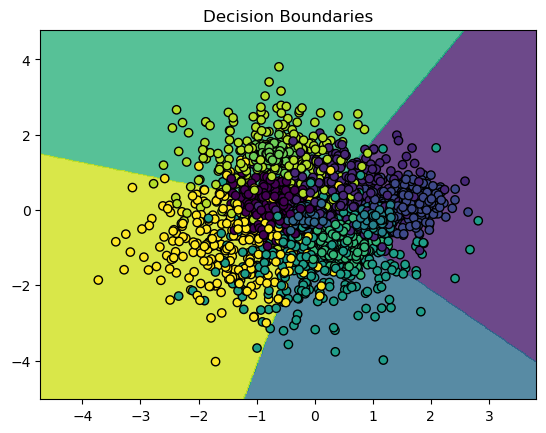

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs

# Define Multi-class Logistic Regression using One-vs-Rest
class MultiClassLogisticRegression:
    def __init__(self, tol=1e-4, n_epochs_no_update=2):
        self.classifiers = []
        self.tol = tol
        self.n_epochs_no_update = n_epochs_no_update
        self.trained_epochs = 0
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_true, y_pred):
        return -np.mean(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))
    
    def fit(self, X, y, lr=0.01, epochs=100, X_val=None, y_val=None, tol=None, n_epochs_no_update=None):
        if tol is not None:
            self.tol = tol
        if n_epochs_no_update is not None:
            self.n_epochs_no_update = n_epochs_no_update
        
        self.classes = np.unique(y)
        self.classifiers = []
        
        for c in self.classes:
            y_binary = (y == c).astype(int)
            clf = LogisticRegression(self.tol, self.n_epochs_no_update)
            clf.fit(X, y_binary, lr=lr, epochs=epochs, X_val=X_val, y_val=(y_val == c).astype(int) if y_val is not None else None)
            self.classifiers.append(clf)
    
    def predict(self, X):
        probs = np.array([clf.predict_probabilities(X) for clf in self.classifiers]).T
        return self.classes[np.argmax(probs, axis=1)]
    
    def predict_probabilities(self, X):
        return np.array([clf.predict_probabilities(X) for clf in self.classifiers]).T

    
# Define Multinomial Logistic Regression (Softmax Classifier) for IN4050 task
class SoftmaxRegression:
    def __init__(self, tol=1e-4, n_epochs_no_update=2):
        self.tol = tol
        self.n_epochs_no_update = n_epochs_no_update
        self.trained_epochs = 0
    
    # this model uses softmax function instead of sigmoid
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def categorical_cross_entropy(self, y_true, y_pred):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))
    
    def fit(self, X, y, lr=0.01, epochs=100, X_val=None, y_val=None, tol=None, n_epochs_no_update=None):
        if tol is not None:
            self.tol = tol
        if n_epochs_no_update is not None:
            self.n_epochs_no_update = n_epochs_no_update
        
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        self.weights = np.random.randn(X.shape[1], self.n_classes)
        self.bias = np.zeros((1, self.n_classes))
        
        y_one_hot = np.eye(self.n_classes)[y]
        best_loss = float('inf')
        epochs_since_update = 0
        
        for epoch in range(epochs):
            logits = np.dot(X, self.weights) + self.bias
            probs = self.softmax(logits)
            loss = self.categorical_cross_entropy(y_one_hot, probs)
            
            grad_w = np.dot(X.T, (probs - y_one_hot)) / X.shape[0]
            grad_b = np.mean(probs - y_one_hot, axis=0, keepdims=True)
            
            self.weights -= lr * grad_w
            self.bias -= lr * grad_b
            
            if X_val is not None and y_val is not None:
                y_val_one_hot = np.eye(self.n_classes)[y_val]
                val_logits = np.dot(X_val, self.weights) + self.bias
                val_probs = self.softmax(val_logits)
                val_loss = self.categorical_cross_entropy(y_val_one_hot, val_probs)
                
                if best_loss - val_loss < self.tol:
                    epochs_since_update += 1
                else:
                    epochs_since_update = 0
                    best_loss = val_loss
                
                if epochs_since_update >= self.n_epochs_no_update:
                    break
            
        self.trained_epochs = epoch + 1
    
    def predict(self, X):
        logits = np.dot(X, self.weights) + self.bias
        probs = self.softmax(logits)
        return np.argmax(probs, axis=1)
    
    def predict_probabilities(self, X):
        logits = np.dot(X, self.weights) + self.bias
        return self.softmax(logits)

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t_multi_train, X_val, t_multi_val):
    results = {}
    times = {}
    
    for lr in learning_rates:
        for epochs in epochs_list:
            for tol in tol_list:
                for n_epochs_no_update in n_epochs_no_update_list:
                    clf = MultiClassLogisticRegression(tol=tol, n_epochs_no_update=n_epochs_no_update)
                    start_time = time.time()
                    clf.fit(X_train, t_multi_train, lr=lr, epochs=epochs, X_val=X_val, y_val=t_multi_val)
                    elapsed_time = time.time() - start_time
                    acc = np.mean(clf.predict(X_val) == t_multi_val)
                    results[(lr, epochs, tol, n_epochs_no_update)] = acc
                    times[(lr, epochs, tol, n_epochs_no_update)] = elapsed_time
    
    return results, times

# Define function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
    plt.title("Decision Boundaries")
    plt.show()

# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, scale_factor=1.0)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, scale_factor=1.0)

# Define hyperparameter ranges
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
epochs_list = [10, 50, 100, 500, 1000]
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]

# Run evaluation
results, times = evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train_scaled, t_multi_train, X_val_scaled, t_multi_val)

# Find best hyperparameters
best_params = max(results, key=results.get)
best_lr, best_epochs, best_tol, best_n_epochs_no_update = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Tolerance: {best_tol}, Best n_epochs_no_update: {best_n_epochs_no_update}, Best Accuracy: {results[best_params]:.3f}, Training Time: {times[best_params]:.3f} seconds")

# Train best model
best_clf = MultiClassLogisticRegression(tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
best_clf.fit(X_train_scaled, t_multi_train, lr=best_lr, epochs=best_epochs, X_val=X_val_scaled, y_val=t_multi_val)

# Plot decision boundaries
plot_decision_boundaries(X_train_scaled, t_multi_train, best_clf)

multi_log_reg = best_clf # this is for the final part 3 where you need to evaluate all the models

Best Learning Rate: 1.0, Best Epochs: 500, Best Tolerance: 0.001, Best n_epochs_no_update: 2, Best Accuracy: 0.701, Training Time: 0.241 seconds


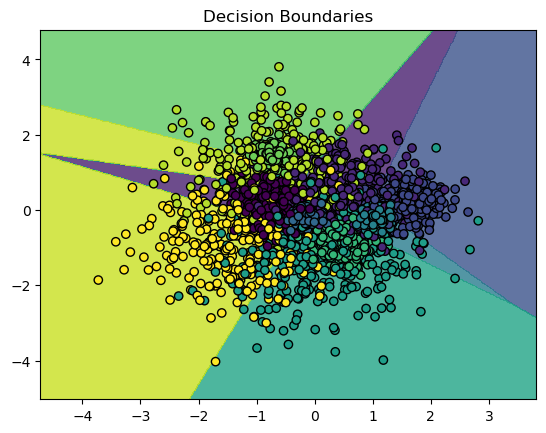

In [19]:
# redone code just replaced evaluation method model inside with SoftmaxRegression
# this is to make it more structured
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs

# Define Multi-class Logistic Regression using One-vs-Rest
class MultiClassLogisticRegression:
    def __init__(self, tol=1e-4, n_epochs_no_update=2):
        self.classifiers = []
        self.tol = tol
        self.n_epochs_no_update = n_epochs_no_update
        self.trained_epochs = 0
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_true, y_pred):
        return -np.mean(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))
    
    def fit(self, X, y, lr=0.01, epochs=100, X_val=None, y_val=None, tol=None, n_epochs_no_update=None):
        if tol is not None:
            self.tol = tol
        if n_epochs_no_update is not None:
            self.n_epochs_no_update = n_epochs_no_update
        
        self.classes = np.unique(y)
        self.classifiers = []
        
        for c in self.classes:
            y_binary = (y == c).astype(int)
            clf = LogisticRegression(self.tol, self.n_epochs_no_update)
            clf.fit(X, y_binary, lr=lr, epochs=epochs, X_val=X_val, y_val=(y_val == c).astype(int) if y_val is not None else None)
            self.classifiers.append(clf)
    
    def predict(self, X):
        probs = np.array([clf.predict_probabilities(X) for clf in self.classifiers]).T
        return self.classes[np.argmax(probs, axis=1)]
    
    def predict_probabilities(self, X):
        return np.array([clf.predict_probabilities(X) for clf in self.classifiers]).T

    
# Define Multinomial Logistic Regression (Softmax Classifier) for IN4050 task
class SoftmaxRegression:
    def __init__(self, tol=1e-4, n_epochs_no_update=2):
        self.tol = tol
        self.n_epochs_no_update = n_epochs_no_update
        self.trained_epochs = 0
    
    # this model uses softmax function instead of sigmoid
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def categorical_cross_entropy(self, y_true, y_pred):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))
    
    def fit(self, X, y, lr=0.01, epochs=100, X_val=None, y_val=None, tol=None, n_epochs_no_update=None):
        if tol is not None:
            self.tol = tol
        if n_epochs_no_update is not None:
            self.n_epochs_no_update = n_epochs_no_update
        
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        self.weights = np.random.randn(X.shape[1], self.n_classes)
        self.bias = np.zeros((1, self.n_classes))
        
        y_one_hot = np.eye(self.n_classes)[y]
        best_loss = float('inf')
        epochs_since_update = 0
        
        for epoch in range(epochs):
            logits = np.dot(X, self.weights) + self.bias
            probs = self.softmax(logits)
            loss = self.categorical_cross_entropy(y_one_hot, probs)
            
            grad_w = np.dot(X.T, (probs - y_one_hot)) / X.shape[0]
            grad_b = np.mean(probs - y_one_hot, axis=0, keepdims=True)
            
            self.weights -= lr * grad_w
            self.bias -= lr * grad_b
            
            if X_val is not None and y_val is not None:
                y_val_one_hot = np.eye(self.n_classes)[y_val]
                val_logits = np.dot(X_val, self.weights) + self.bias
                val_probs = self.softmax(val_logits)
                val_loss = self.categorical_cross_entropy(y_val_one_hot, val_probs)
                
                if best_loss - val_loss < self.tol:
                    epochs_since_update += 1
                else:
                    epochs_since_update = 0
                    best_loss = val_loss
                
                if epochs_since_update >= self.n_epochs_no_update:
                    break
            
        self.trained_epochs = epoch + 1
    
    def predict(self, X):
        logits = np.dot(X, self.weights) + self.bias
        probs = self.softmax(logits)
        return np.argmax(probs, axis=1)
    
    def predict_probabilities(self, X):
        logits = np.dot(X, self.weights) + self.bias
        return self.softmax(logits)

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t_multi_train, X_val, t_multi_val):
    results = {}
    times = {}
    
    for lr in learning_rates:
        for epochs in epochs_list:
            for tol in tol_list:
                for n_epochs_no_update in n_epochs_no_update_list:
                    clf = SoftmaxRegression(tol=tol, n_epochs_no_update=n_epochs_no_update)
                    start_time = time.time()
                    clf.fit(X_train, t_multi_train, lr=lr, epochs=epochs, X_val=X_val, y_val=t_multi_val)
                    elapsed_time = time.time() - start_time
                    acc = np.mean(clf.predict(X_val) == t_multi_val)
                    results[(lr, epochs, tol, n_epochs_no_update)] = acc
                    times[(lr, epochs, tol, n_epochs_no_update)] = elapsed_time
    
    return results, times

# Define function to plot decision boundaries
def plot_decision_boundaries(X, y, model):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
    plt.title("Decision Boundaries")
    plt.show()

# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, scale_factor=1.0)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, scale_factor=1.0)

# Define hyperparameter ranges
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
epochs_list = [10, 50, 100, 500, 1000]
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]

# Run evaluation
results, times = evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train_scaled, t_multi_train, X_val_scaled, t_multi_val)

# Find best hyperparameters
best_params = max(results, key=results.get)
best_lr, best_epochs, best_tol, best_n_epochs_no_update = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Tolerance: {best_tol}, Best n_epochs_no_update: {best_n_epochs_no_update}, Best Accuracy: {results[best_params]:.3f}, Training Time: {times[best_params]:.3f} seconds")

# Train best model
best_clf = SoftmaxRegression(tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
best_clf.fit(X_train_scaled, t_multi_train, lr=best_lr, epochs=best_epochs, X_val=X_val_scaled, y_val=t_multi_val)

# Plot decision boundaries
plot_decision_boundaries(X_train_scaled, t_multi_train, best_clf)

multi_log_reg_multinomial = best_clf # this is for the final part 3 where you need to evaluate all the models

Our classifier is not ideal. But is it because all the 10 classes are equally diffucult to predict?
You should evaluate the multinomial model predictions for each class separately and report your findings.
Please also report whether there is any difference in this respect between the training and the validation sets.

Per-class accuracy on training set: {0: 0.7087378640776699, 1: 0.5100671140939598, 2: 0.8969072164948454, 3: 0.9585987261146497, 4: 0.9006622516556292, 5: 0.42105263157894735, 6: 0.5257731958762887, 7: 0.9251700680272109, 8: 0.2159468438538206, 9: 0.6486486486486487}
Per-class accuracy on validation set: {0: 0.6989247311827957, 1: 0.5454545454545454, 2: 0.9722222222222222, 3: 0.967032967032967, 4: 0.9215686274509803, 5: 0.46153846153846156, 6: 0.5882352941176471, 7: 0.9191919191919192, 8: 0.2549019607843137, 9: 0.66}


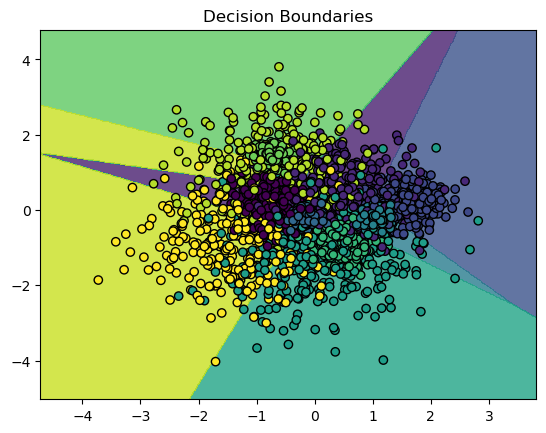

In [20]:
def evaluate_per_class_accuracy(model, X, y):
    predictions = model.predict(X)
    class_labels = np.unique(y)
    accuracies = {}
    
    for cls in class_labels:
        cls_mask = (y == cls)
        accuracies[cls] = np.mean(predictions[cls_mask] == y[cls_mask])
        
    return accuracies

# Evaluate per-class accuracy
train_class_accuracy = evaluate_per_class_accuracy(best_clf, X_train_scaled, t_multi_train)
val_class_accuracy = evaluate_per_class_accuracy(best_clf, X_val_scaled, t_multi_val)

print("Per-class accuracy on training set:", train_class_accuracy)
print("Per-class accuracy on validation set:", val_class_accuracy)

plot_decision_boundaries(X_train_scaled, t_multi_train, best_clf)

# comment:
# it seems to predict above 60% accuracy for the classes {0, 2, 3, 4, 7 9} which is 6/10 classes, in the training set
# very similar result for the validation set, the biggest classes that the model has a problem predicting is class 8
# this is based on the softmax classifier model

# Part 2 Multi-layer neural networks

## A first non-linear classifier

The following code is a simple implementation of a multi-layer perceptron or feed-forward neural network.
For now, it is quite restricted.
There is only one hidden layer with 6 neurons.
It can only handle binary classification.
In addition, it uses a simple final layer similar to the linear regression classifier above.
One way to look at it is what happens when we add a hidden layer to the linear regression classifier.

The MLP class below misses the implementation of the `forward()` function. Your first task is to implement it. 

Remember that in the forward pass, we "feed" the input to the model, the model processes it and produces the output. The function should make use of the logistic activation function and bias.

In [21]:
# First, we define the logistic function and its derivative:
def logistic(x):
    return 1/(1+np.exp(-x))

def logistic_diff(y):
    return y * (1 - y)

calculating learning rates :  0.001  to  0.101


/tmp/ipykernel_521/702837997.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


calculating learning rates :  0.1  to  0.2
calculating learning rates :  0.2  to  0.3
Best Learning Rate: 0.003, Best Epochs: 1000, Best Accuracy: 0.864
best model accuracy:  0.871
elapsed time:  362.3178639411926


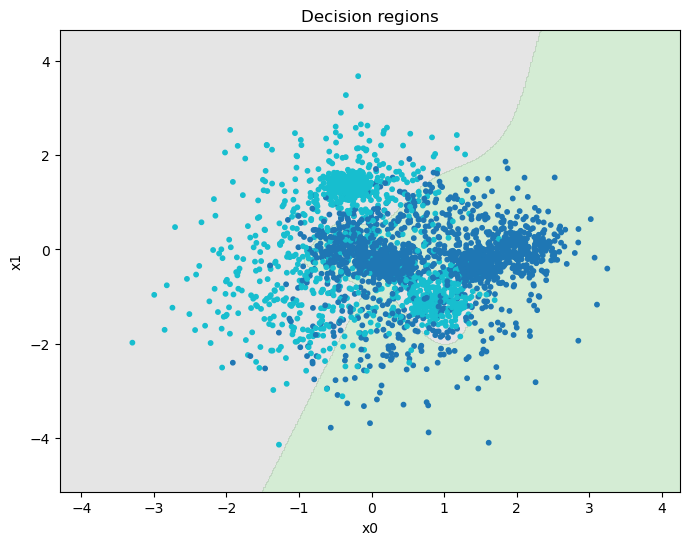

In [22]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        
        self.activ_diff = logistic_diff
        
    # part 2 task: forward implementation here:
    def forward(self, X):
        """Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer."""

        # Compute activations for the hidden layer
        hidden_inputs = X @ self.weights1  # Linear combination
        hidden_outs = self.activ(hidden_inputs)  # Apply activation function

        # Add bias term to the hidden layer output
        hidden_outs = np.hstack([np.ones((hidden_outs.shape[0], 1)) * self.bias, hidden_outs])

        # Compute activations for the output layer
        final_inputs = hidden_outs @ self.weights2  # Linear combination
        outputs = self.activ(final_inputs)  # Apply activation function

        return hidden_outs, outputs
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        for e in range(epochs):
            # One epoch
            # The forward step:
            hidden_outs, outputs = self.forward(X_train_bias)
            # The delta term on the output node:
            out_deltas = (outputs - T_train)
            # The delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # The deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            # Update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 
            
    
    def predict(self, X):
        """Predict the class for the members of X"""
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score= forw[:, 0]
        return (score > 0.5)
    

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t2_train, X_val, t2_val):
    results = {}
    
    for lr in learning_rates:
        print("calculating learning rates : ", lr, " to ", round(lr + 0.1, 5))
        for epochs in epochs_list:
            for i in range(0,100):
                i = i / 1000
                #print(lr, i, float(lr + i)) # debugging prints out the learning rate after applying a small step
                lr_temp = round(lr+i, 5)
                clf = MLPBinaryLinRegClass()
                clf.fit(X_train, t2_train, lr=lr_temp, epochs=epochs)
                acc = accuracy(clf.predict(X_val), t2_val)
                results[(lr_temp, epochs)] = acc # task E: shows how much it trained for in the results
                
    
    return results

# Manual feature scaling (Standardization) with adjustable scaling factor
def standardize_data(X, mean=None, std=None, scale_factor=1.0):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Prevent division by zero
    return ((X - mean) / std) * scale_factor, mean, std
    
# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, 1)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, 1)

# Define hyperparameter ranges
learning_rates = [0.001, 0.1, 0.2]
epochs_list = [1000] # because of task E: it has inbuild epoch stopping if the validation data does not detect improvement
# task F: adding tof and n_epochs_no_update as experimenting parameters
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]


# run evaluation
results_scaled = evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train_scaled, t2_train, X_val_scaled, t2_val)

# Find best hyperparameters
best_params = max(results_scaled, key=results_scaled.get)
best_lr, best_epochs = best_params
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Accuracy: {results_scaled[best_params]:.3f}")

# now I just put the best learning rate and epochs into the function to validate the data and make a plot
# best_clf = MLPBinaryLinRegClass(tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
best_clf = MLPBinaryLinRegClass()
best_clf.fit(X_train_scaled, t2_train, lr=best_lr, epochs=best_epochs)
print("best model accuracy: ", accuracy(best_clf.predict(X_val_scaled), t2_val))
#print(regClassScaled.predict_probabilities(X_val_scaled))


# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_regions(X_train_scaled, t2_train, best_clf)

When implemented, this model can be used to make a non-linear classifier for the set `(X, t2)`. Experiment with settings for learning rate and epochs and see how good results you can get. 
Report results for various settings. Be prepared to train for a long time (but you can control it via the number of epochs and hidden size). 

Plot the training set together with the decision regions as in Part I.

In [23]:
# The MLP model is performing better than the logistic regression model, the logistic regression model outputed around 0.76 and the MLP model has an accuracy of 0.876 which is a huge improvement especially since the data is not lineraly seperable 

# Improving the MLP classifier
You should now make changes to the classifier similarly to what you did with the logistic regression classifier in part 1.

a) In addition to the `predict()` method, which predicts a class for the data, include the `predict_probabilities()` method which predict the probability of the data belonging to the positive class. The training should be based on these values, as with logistic regression.

b) Calculate the loss and the accuracy after each epoch and store them for inspection after training.

c) Extend the `fit()` method with optional arguments for a validation set `(X_val, t_val)`. If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch.

d) Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved for more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 2. Add an attribute to the classifier which tells us after fitting how many epochs it was trained on.

e) Tune the hyper-parameters: `lr`, `tol` and `dim-hidden` (size of the hidden layer).
Also, consider the effect of scaling the data.

f) After a succesful training with the best setting for the hyper-parameters, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see.

g) The MLP algorithm contains an element of non-determinism. Hence, train the classifier 3 times with the optimal hyper-parameters and report the mean and standard deviation of the accuracies over the 3 runs.

lr = 0.001, epochs = 200, tol = 0.0001, n_epochs_no_update = 2 => Mean Accuracy: 0.8210, Std Dev: 0.0153
lr = 0.001, epochs = 346, tol = 0.0001, n_epochs_no_update = 5 => Mean Accuracy: 0.8433, Std Dev: 0.0017
lr = 0.001, epochs = 543, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.8447, Std Dev: 0.0005
lr = 0.001, epochs = 17, tol = 0.001, n_epochs_no_update = 2 => Mean Accuracy: 0.7590, Std Dev: 0.0022
lr = 0.001, epochs = 28, tol = 0.001, n_epochs_no_update = 5 => Mean Accuracy: 0.7677, Std Dev: 0.0130
lr = 0.001, epochs = 166, tol = 0.001, n_epochs_no_update = 10 => Mean Accuracy: 0.8183, Std Dev: 0.0136
lr = 0.001, epochs = 6, tol = 0.01, n_epochs_no_update = 2 => Mean Accuracy: 0.7157, Std Dev: 0.0478
lr = 0.001, epochs = 21, tol = 0.01, n_epochs_no_update = 5 => Mean Accuracy: 0.7580, Std Dev: 0.0024
lr = 0.001, epochs = 24, tol = 0.01, n_epochs_no_update = 10 => Mean Accuracy: 0.7587, Std Dev: 0.0017
lr = 0.1, epochs = 4, tol = 0.0001, n_epochs_no_update = 2 => Mean 

/tmp/ipykernel_521/702837997.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


lr = 0.1, epochs = 30, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.5213, Std Dev: 0.1673
lr = 0.1, epochs = 3, tol = 0.001, n_epochs_no_update = 2 => Mean Accuracy: 0.5970, Std Dev: 0.0000
lr = 0.1, epochs = 12, tol = 0.001, n_epochs_no_update = 5 => Mean Accuracy: 0.6293, Std Dev: 0.0650
lr = 0.1, epochs = 18, tol = 0.001, n_epochs_no_update = 10 => Mean Accuracy: 0.5080, Std Dev: 0.1485
lr = 0.1, epochs = 3, tol = 0.01, n_epochs_no_update = 2 => Mean Accuracy: 0.5323, Std Dev: 0.0915
lr = 0.1, epochs = 6, tol = 0.01, n_epochs_no_update = 5 => Mean Accuracy: 0.5890, Std Dev: 0.1487
lr = 0.1, epochs = 16, tol = 0.01, n_epochs_no_update = 10 => Mean Accuracy: 0.5323, Std Dev: 0.0915
lr = 0.2, epochs = 3, tol = 0.0001, n_epochs_no_update = 2 => Mean Accuracy: 0.5970, Std Dev: 0.0000
lr = 0.2, epochs = 11, tol = 0.0001, n_epochs_no_update = 5 => Mean Accuracy: 0.6513, Std Dev: 0.0768
lr = 0.2, epochs = 11, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.7247, Std D

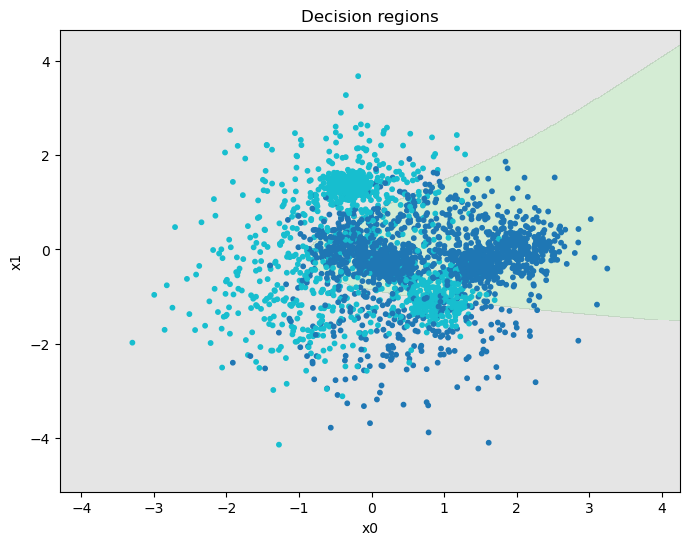

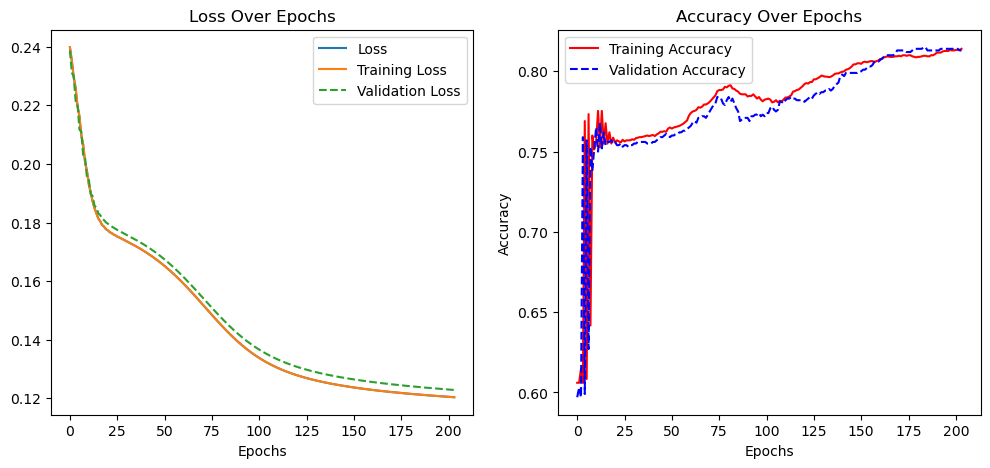

In [24]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        
        self.activ_diff = logistic_diff
        # MLP task b: calculating the loss and the accuracy after each epoch and store them for inspection after training
        self.loss_history = []  # Store loss per epoch
        self.accuracy_history = []  # Store accuracy per epoch
        # MLP task c: store validation loss
        self.val_losses = []  # Store validation loss
        self.val_accuracies = []  # Store validation accuracy
        # MLP task d: store the amount of epochs that are trained / attribute that tells how many epochs it was trained on
        self.n_epochs_trained = 0  # Store number of epochs trained
        
    # part 2 task: forward implementation here:
    def forward(self, X):
        """Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer."""

        # Compute activations for the hidden layer
        hidden_inputs = X @ self.weights1  # Linear combination
        hidden_outs = self.activ(hidden_inputs)  # Apply activation function

        # Add bias term to the hidden layer output
        hidden_outs = np.hstack([np.ones((hidden_outs.shape[0], 1)) * self.bias, hidden_outs])

        # Compute activations for the output layer
        final_inputs = hidden_outs @ self.weights2  # Linear combination
        outputs = self.activ(final_inputs)  # Apply activation function

        return hidden_outs, outputs
    
    def fit(self, X_train, t_train, lr=0.001, epochs = 100, X_val=None, t_val=None, tol=1e-4, n_epochs_no_update=2):
        """Initialize the weights. Train *epochs* many epochs.
        
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = lr
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(
            dim_in + 1, 
            self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand(
            self.dim_hidden+1, 
            dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        # Variables to track early stopping
        best_loss = float('inf')
        epochs_no_update = 0
        
        for e in range(epochs):
            # One epoch
            # The forward step:
            hidden_outs, outputs = self.forward(X_train_bias)
            # The delta term on the output node:
            out_deltas = (outputs - T_train)
            # The delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # The deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * 
                                self.activ_diff(hidden_outs[:, 1:]))  

            # Update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 
            
            # MLP Task b: Calculate loss and accuracy
            loss = np.mean((outputs - T_train) ** 2)
            acc = accuracy((outputs[:, 0] > 0.5), t_train)
            self.loss_history.append(loss)
            self.accuracy_history.append(acc)
            
            # MLP Task C: If validation set is provided, calculate and store loss and accuracy for validation set
            if X_val is not None and t_val is not None:
                X_val_bias = add_bias(X_val, self.bias)
                hidden_outs_val, outputs_val = self.forward(X_val_bias)
                val_loss = np.mean((outputs_val - t_val.reshape(-1, 1)) ** 2)
                val_accuracy = accuracy(self.predict(X_val), t_val)
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_accuracy)
                
                # MLP task d: Early stopping logic
                if val_loss < best_loss - tol:
                    best_loss = val_loss
                    epochs_no_update = 0  # Reset counter
                else:
                    epochs_no_update += 1
                    if epochs_no_update >= n_epochs_no_update:
                        break
                    
        self.n_epochs_trained = e + 1  # Store the number of epochs trained
                    
            
    # MLP task A: adding a predict propabilities method
    def predict_probabilities(self, X):
        """Predict the probability of belonging to the positive class"""
        Z = add_bias(X, self.bias)
        return self.forward(Z)[1]  # Return final layer outputs
    
    
    def predict(self, X):
        """Predict the class for the members of X"""
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score= forw[:, 0]
        return (score > 0.5)
    

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t2_train, X_val, t2_val, n_runs=3):
    results = {}
    
    for lr in learning_rates:
        for epochs in epochs_list:
            for tol in tol_list:
                for n_epochs_no_update in n_epochs_no_update_list:
                    accuracies = []
                    for _ in range(n_runs):
                        # Create and train the model
                        clf = MLPBinaryLinRegClass()
                        clf.fit(X_train_scaled, t2_train, lr=lr, epochs=epochs, X_val=X_val, t_val=t2_val, tol=tol, n_epochs_no_update=n_epochs_no_update)

                        # Evaluate the model using probabilities
                        probabilities = clf.predict_probabilities(X_val)
                        predictions = (probabilities[:, 0] > 0.5)  # Convert to binary class predictions
                        acc = accuracy(predictions, t2_val)
                        accuracies.append(acc)
                        #print(f"lr = {lr}, epochs = {epochs}, tol = {tol}, n_epochs_no_update = {n_epochs_no_update} => Validation Accuracy: {acc:.4f}")
                    
                    # Calculate mean and standard deviation
                    mean_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    results[(lr, clf.n_epochs_trained, tol, n_epochs_no_update)] = (mean_acc, std_acc)
                    print(f"lr = {lr}, epochs = {clf.n_epochs_trained}, tol = {tol}, n_epochs_no_update = {n_epochs_no_update} => "
                          f"Mean Accuracy: {mean_acc:.4f}, Std Dev: {std_acc:.4f}")
    
    return results

# Manual feature scaling (Standardization) with adjustable scaling factor
def standardize_data(X, mean=None, std=None, scale_factor=1.0):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Prevent division by zero
    return ((X - mean) / std) * scale_factor, mean, std
    
# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, 1)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, 1)

# Define hyperparameter ranges
learning_rates = [0.001, 0.1, 0.2]
epochs_list = [1000] # because of task E: it has inbuild epoch stopping if the validation data does not detect improvement
# task F: adding tof and n_epochs_no_update as experimenting parameters
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]


# run evaluation
results_scaled = evaluate_hyperparameters(
    learning_rates, epochs_list, tol_list, n_epochs_no_update_list, 
    X_train_scaled, t2_train, X_val_scaled, t2_val, n_runs=3
)

# Find best hyperparameters
best_params = max(results_scaled, key=lambda x: results_scaled[x][0])
best_lr, best_epochs, best_tol, best_n_epochs_no_update = best_params
# task g: mean and std
mean_acc, std_acc = results_scaled[best_params] 
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Tolerance: {best_tol}, "
      f"Best n_epochs_no_update: {best_n_epochs_no_update}, "
      f"Mean Accuracy: {mean_acc:.3f}, Std Dev: {std_acc:.3f}")
# now I just put the best learning rate and epochs into the function to validate the data and make a plot
# best_clf = MLPBinaryLinRegClass(tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
best_clf = MLPBinaryLinRegClass()
best_clf.fit(X_train_scaled, t2_train, lr=best_lr, epochs=best_epochs, X_val=X_val_scaled, t_val=t2_val)
print("best model accuracy: ", accuracy(best_clf.predict(X_val_scaled), t2_val))
#print(regClassScaled.predict_probabilities(X_val_scaled))


# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_regions(X_train_scaled, t2_train, best_clf)

# task f: Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_clf.loss_history, label='Loss')
plt.xlabel('Epochs')
plt.plot(best_clf.loss_history, label='Training Loss')
plt.plot(best_clf.val_losses, label='Validation Loss', linestyle='dashed')
plt.title('Loss Over Epochs')
plt.legend()

# task f
plt.subplot(1, 2, 2)
plt.plot(best_clf.accuracy_history, label='Training Accuracy', color='red')
plt.plot(best_clf.val_accuracies, label='Validation Accuracy', color='blue', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

mlp = best_clf # this is for the final part 3 where you need to evaluate all the models

# MLP task f: comment:
# I notice that the lines are more curvy than the logistic regression, for example how it plummits the loss really fast the beginning but then starts to slow down and longer epochs are required to see consistent reduction
# Also I noticed how the accuracy for validation data doesn't instantly reach it peak but it requires more training and also over time there is more variation in the accuracy over epochs.
# It does feel to me that this is slowly becoming this search space optimization where it also depends on the random weights that was assigned to the algorithm 

## For IN4050-students: Multi-class neural network

The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. This is the most fun part of the set :) )

The goal is to use a feed-forward neural network for non-linear multi-class classfication and apply it to the set `(X, t_multi)`.

Modify the network to become a multi-class multinomial classifier. As a sanity check of your implementation, you may apply it to `(X, t_2)` and see whether you get similar results as above.

Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Plot the decision boundaries for your best classifier. Evaluate the  best model predictions for each class separately (same as in part 1)  and report your findings. Please also report whether there is any difference in this respect between the training and the validation sets.

lr = 0.001, epochs = 1000, tol = 0.0001, n_epochs_no_update = 2 => Mean Accuracy: 0.7277, Std Dev: 0.0104
lr = 0.001, epochs = 1000, tol = 0.0001, n_epochs_no_update = 5 => Mean Accuracy: 0.7430, Std Dev: 0.0070
lr = 0.001, epochs = 1000, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.7330, Std Dev: 0.0054
lr = 0.001, epochs = 309, tol = 0.001, n_epochs_no_update = 2 => Mean Accuracy: 0.7127, Std Dev: 0.0063
lr = 0.001, epochs = 498, tol = 0.001, n_epochs_no_update = 5 => Mean Accuracy: 0.7273, Std Dev: 0.0118
lr = 0.001, epochs = 691, tol = 0.001, n_epochs_no_update = 10 => Mean Accuracy: 0.7317, Std Dev: 0.0087
lr = 0.001, epochs = 51, tol = 0.01, n_epochs_no_update = 2 => Mean Accuracy: 0.6547, Std Dev: 0.0127
lr = 0.001, epochs = 107, tol = 0.01, n_epochs_no_update = 5 => Mean Accuracy: 0.6993, Std Dev: 0.0082
lr = 0.001, epochs = 186, tol = 0.01, n_epochs_no_update = 10 => Mean Accuracy: 0.7063, Std Dev: 0.0056
lr = 0.1, epochs = 4, tol = 0.0001, n_epochs_no_update = 2 

/tmp/ipykernel_521/702837997.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-x))


lr = 0.1, epochs = 13, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.1363, Std Dev: 0.0207
lr = 0.1, epochs = 4, tol = 0.001, n_epochs_no_update = 2 => Mean Accuracy: 0.1240, Std Dev: 0.0311
lr = 0.1, epochs = 8, tol = 0.001, n_epochs_no_update = 5 => Mean Accuracy: 0.1000, Std Dev: 0.0014
lr = 0.1, epochs = 13, tol = 0.001, n_epochs_no_update = 10 => Mean Accuracy: 0.1140, Std Dev: 0.0114
lr = 0.1, epochs = 4, tol = 0.01, n_epochs_no_update = 2 => Mean Accuracy: 0.1403, Std Dev: 0.0495
lr = 0.1, epochs = 9, tol = 0.01, n_epochs_no_update = 5 => Mean Accuracy: 0.1400, Std Dev: 0.0353
lr = 0.1, epochs = 13, tol = 0.01, n_epochs_no_update = 10 => Mean Accuracy: 0.1500, Std Dev: 0.0414
lr = 0.2, epochs = 7, tol = 0.0001, n_epochs_no_update = 2 => Mean Accuracy: 0.0980, Std Dev: 0.0050
lr = 0.2, epochs = 7, tol = 0.0001, n_epochs_no_update = 5 => Mean Accuracy: 0.1473, Std Dev: 0.0356
lr = 0.2, epochs = 13, tol = 0.0001, n_epochs_no_update = 10 => Mean Accuracy: 0.1170, Std Dev

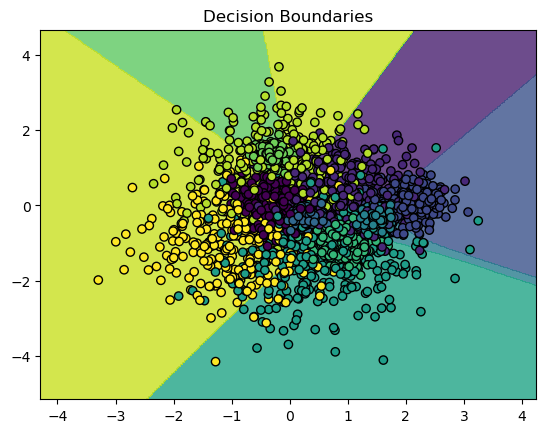

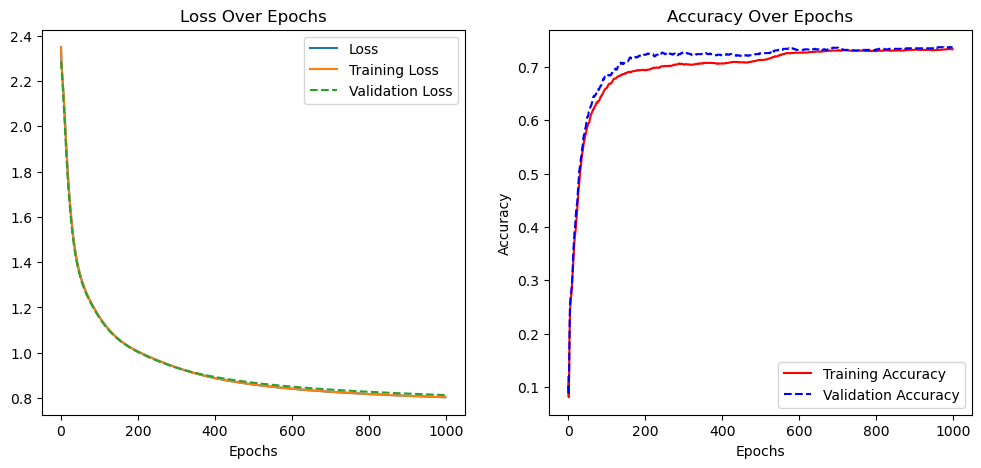

In [25]:
import numpy as np

class MLPMultiClass(NumpyClassifier):
    """A multi-layer neural network for multi-class classification with one hidden layer"""
    
    def __init__(self, num_classes, bias=-1, dim_hidden=6):
        """Initialize the hyperparameters"""
        self.num_classes = num_classes
        self.bias = bias
        self.dim_hidden = dim_hidden
        
        self.activ = logistic
        self.activ_diff = logistic_diff
        self.loss_history = []
        self.accuracy_history = []
        self.val_losses = []
        self.val_accuracies = []
        self.n_epochs_trained = 0

    def softmax(self, Z):
        """Compute softmax activation"""
        expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))  # Stability trick
        return expZ / np.sum(expZ, axis=1, keepdims=True)

    def forward(self, X):
        """Perform forward propagation and return hidden and output layer activations."""
        hidden_inputs = X @ self.weights1
        hidden_outs = self.activ(hidden_inputs)  
        hidden_outs = np.hstack([np.ones((hidden_outs.shape[0], 1)) * self.bias, hidden_outs])  # Add bias
        final_inputs = hidden_outs @ self.weights2
        outputs = self.softmax(final_inputs)  # Softmax for multi-class
        return hidden_outs, outputs

    def compute_loss(self, outputs, T_train):
        """Compute categorical cross-entropy loss"""
        return -np.mean(np.sum(T_train * np.log(outputs + 1e-9), axis=1))  # Small epsilon for numerical stability

    def fit(self, X_train, t_train, lr=0.001, epochs=100, X_val=None, t_val=None, tol=1e-4, n_epochs_no_update=2):
        """Train the multi-layer perceptron for multi-class classification."""
        self.lr = lr
        T_train = one_hot_encode(t_train, self.num_classes)  # Convert to one-hot encoding
        dim_in = X_train.shape[1]
        dim_out = self.num_classes
        
        # Initialize weights
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1) / np.sqrt(dim_in)
        self.weights2 = (np.random.rand(self.dim_hidden + 1, dim_out) * 2 - 1) / np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)

        best_loss = float('inf')
        epochs_no_update = 0

        for e in range(epochs):
            hidden_outs, outputs = self.forward(X_train_bias)
            out_deltas = outputs - T_train  # Gradient for softmax + cross-entropy
            hiddenout_diffs = out_deltas @ self.weights2.T
            hiddenact_deltas = (hiddenout_diffs[:, 1:] * self.activ_diff(hidden_outs[:, 1:]))

            # Update weights
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas

            loss = self.compute_loss(outputs, T_train)
            acc = accuracy(self.predict(X_train), t_train)
            self.loss_history.append(loss)
            self.accuracy_history.append(acc)

            if X_val is not None and t_val is not None:
                X_val_bias = add_bias(X_val, self.bias)
                hidden_outs_val, outputs_val = self.forward(X_val_bias)
                val_loss = self.compute_loss(outputs_val, one_hot_encode(t_val, self.num_classes))
                val_accuracy = accuracy(self.predict(X_val), t_val)
                self.val_losses.append(val_loss)
                self.val_accuracies.append(val_accuracy)

                if val_loss < best_loss - tol:
                    best_loss = val_loss
                    epochs_no_update = 0
                else:
                    epochs_no_update += 1
                    if epochs_no_update >= n_epochs_no_update:
                        break

        self.n_epochs_trained = e + 1

    def predict_probabilities(self, X):
        """Predict probability distributions for each class."""
        Z = add_bias(X, self.bias)
        return self.forward(Z)[1]

    def predict(self, X):
        """Predict the most likely class for each data point."""
        probabilities = self.predict_probabilities(X)
        return np.argmax(probabilities, axis=1)  # Return class with highest probability


def one_hot_encode(y, num_classes):
    """Convert labels to one-hot encoding"""
    return np.eye(num_classes)[y]

# Define function to evaluate hyperparameter settings
def evaluate_hyperparameters(learning_rates, epochs_list, tol_list, n_epochs_no_update_list, X_train, t2_train, X_val, t2_val, num_classes, n_runs=3):
    """
    Evaluates different hyperparameter settings for MLPMultiClass.
    
    Parameters:
        learning_rates: List of learning rates to test.
        epochs_list: List of epoch values to test.
        tol_list: List of tolerance values for early stopping.
        n_epochs_no_update_list: List of patience values for early stopping.
        X_train, t_train: Training data and labels.
        X_val, t_val: Validation data and labels.
        num_classes: Number of classes for classification.
        n_runs: Number of times to run each configuration (default: 3).
        
    Returns:
        results: Dictionary mapping hyperparameter settings to (mean accuracy, std deviation).
    """
    results = {}
    
    for lr in learning_rates:
        for epochs in epochs_list:
            for tol in tol_list:
                for n_epochs_no_update in n_epochs_no_update_list:
                    accuracies = []
                    
                    for _ in range(n_runs):
                        # Initialize model with correct num_classes
                        clf = MLPMultiClass(num_classes=num_classes)  
                        
                        # Train the model
                        clf.fit(X_train, t2_train, lr=lr, epochs=epochs, X_val=X_val, t_val=t2_val, 
                                tol=tol, n_epochs_no_update=n_epochs_no_update)

                        # Get class predictions
                        predictions = clf.predict(X_val)  # Returns class indices (not probabilities)
                        
                        # Calculate accuracy
                        acc = np.mean(predictions == t2_val)  # Multi-class accuracy
                        accuracies.append(acc)
                    
                    # Compute mean & standard deviation
                    mean_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    
                    # Store results
                    results[(lr, clf.n_epochs_trained, tol, n_epochs_no_update)] = (mean_acc, std_acc)
                    
                    # Print results
                    print(f"lr = {lr}, epochs = {clf.n_epochs_trained}, tol = {tol}, "
                          f"n_epochs_no_update = {n_epochs_no_update} => Mean Accuracy: {mean_acc:.4f}, Std Dev: {std_acc:.4f}")
    
    return results

# Manual feature scaling (Standardization) with adjustable scaling factor
def standardize_data(X, mean=None, std=None, scale_factor=1.0):
    if mean is None:
        mean = np.mean(X, axis=0)
    if std is None:
        std = np.std(X, axis=0)
        std[std == 0] = 1  # Prevent division by zero
    return ((X - mean) / std) * scale_factor, mean, std
    
# Scale the data
X_train_scaled, mean, std = standardize_data(X_train, 1)
X_val_scaled, _, _ = standardize_data(X_val, mean, std, 1)

# Define hyperparameter ranges
learning_rates = [0.001, 0.1, 0.2]
epochs_list = [1000] # because of task E: it has inbuild epoch stopping if the validation data does not detect improvement
# task F: adding tof and n_epochs_no_update as experimenting parameters
tol_list = [1e-4, 1e-3, 1e-2]
n_epochs_no_update_list = [2, 5, 10]

n_classes = np.unique(t_multi).size  # Automatically get the number of classes

# run evaluation
results_scaled = evaluate_hyperparameters(
    learning_rates, epochs_list, tol_list, n_epochs_no_update_list, 
    X_train_scaled, t_multi_train, X_val_scaled, t_multi_val, num_classes=n_classes, n_runs=3
)

# Find best hyperparameters
best_params = max(results_scaled, key=lambda x: results_scaled[x][0])
best_lr, best_epochs, best_tol, best_n_epochs_no_update = best_params
# task g: mean and std
mean_acc, std_acc = results_scaled[best_params] 
print(f"Best Learning Rate: {best_lr}, Best Epochs: {best_epochs}, Best Tolerance: {best_tol}, "
      f"Best n_epochs_no_update: {best_n_epochs_no_update}, "
      f"Mean Accuracy: {mean_acc:.3f}, Std Dev: {std_acc:.3f}")
# now I just put the best learning rate and epochs into the function to validate the data and make a plot
best_clf = MLPMultiClass(n_classes)
best_clf.fit(X_train_scaled, t_multi_train, lr=best_lr, epochs=best_epochs, X_val=X_val_scaled, t_val=t_multi_val, tol=best_tol, n_epochs_no_update=best_n_epochs_no_update)
print("best model accuracy: ", accuracy(best_clf.predict(X_val_scaled), t2_val))
#print(regClassScaled.predict_probabilities(X_val_scaled))


# time measured
elapsed_time = time.time() - start_time
print("elapsed time: ", elapsed_time)

plot_decision_boundaries(X_train_scaled, t_multi_train, best_clf)

# task f: Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(best_clf.loss_history, label='Loss')
plt.xlabel('Epochs')
plt.plot(best_clf.loss_history, label='Training Loss')
plt.plot(best_clf.val_losses, label='Validation Loss', linestyle='dashed')
plt.title('Loss Over Epochs')
plt.legend()

# task f
plt.subplot(1, 2, 2)
plt.plot(best_clf.accuracy_history, label='Training Accuracy', color='red')
plt.plot(best_clf.val_accuracies, label='Validation Accuracy', color='blue', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

# MLP task f: comment:
# I notice that the lines are more curvy than the logistic regression, for example how it plummits the loss really fast the beginning but then starts to slow down and longer epochs are required to see consistent reduction
# Also I noticed how the accuracy for validation data doesn't instantly reach it peak but it requires more training and also over time there is more variation in the accuracy over epochs.
# It does feel to me that this is slowly becoming this search space optimization where it also depends on the random weights that was assigned to the algorithm 

mlp_multi = best_clf # this is for the final part 3 where you need to evaluate all the models

# Part III: Final testing
We can now perform a final testing on the held-out test set we created in the beginning.

## Binary task (X, t2)
Consider the linear regression classifier, the logistic regression classifier and the multi-layer network with the best settings you found. Train each of them on the training set and evaluate on the held-out test set, but also on the validation set and the training set. Report the performance in a 3 by 3 table.

Comment on what you see. How do the three different algorithms compare? Also, compare the results between the different dataset splits. In cases like these, one might expect slightly inferior results on the held-out test data compared to the validation and training data. Is this the case? 

Also report precision and recall for class 1.

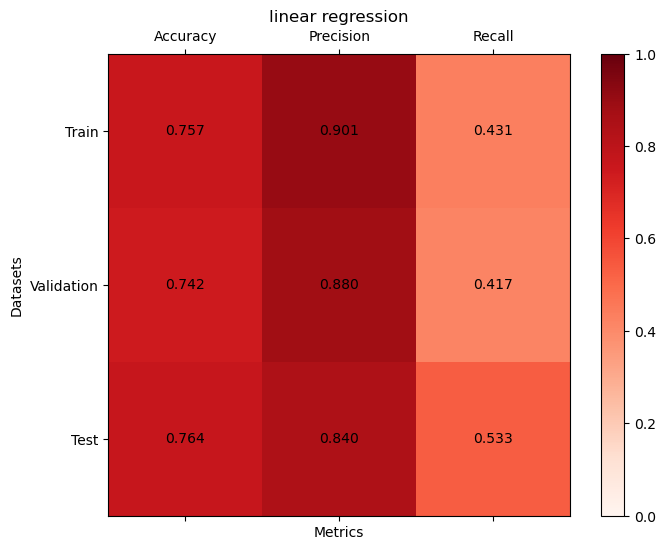

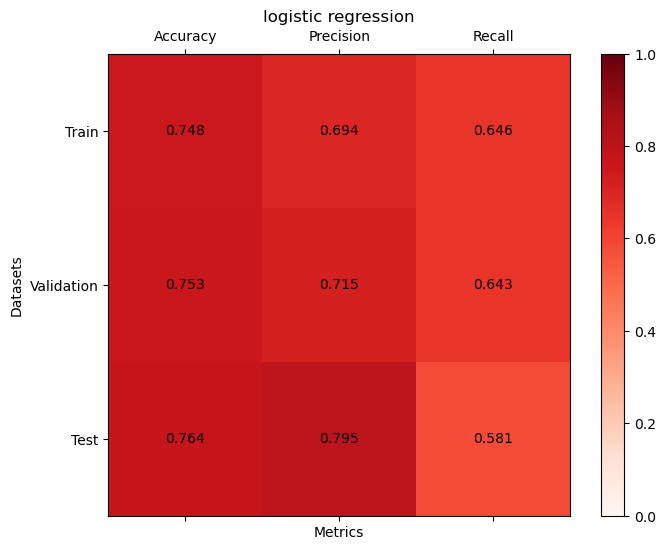

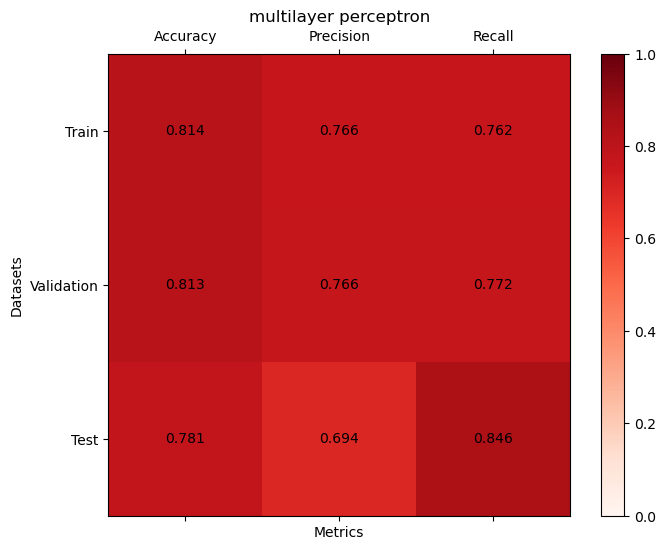

In [26]:
import numpy as np

def precision_recall(y_true, y_pred):
    # True Positives (TP): Model predicts 1, and actual is 1
    TP = np.sum((y_pred == 1) & (y_true == 1))
    
    # False Positives (FP): Model predicts 1, but actual is 0
    FP = np.sum((y_pred == 1) & (y_true == 0))
    
    # False Negatives (FN): Model predicts 0, but actual is 1
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    # Precision = TP / (TP + FP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    
    # Recall = TP / (TP + FN)
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    
    return precision, recall

# Function to evaluate models
def evaluate_model(model, X, y):
    predictions = model.predict(X)

    if isinstance(model, NumpyLinRegClass):  # Convert continuous output to binary
        predictions = np.round(predictions)

    acc = np.mean(predictions == y)  # Accuracy
    prec, rec = precision_recall(y, predictions)  # Compute precision and recall

    return acc, prec, rec

# linear_reg 
# logistic_reg 
# mlp

def plot_model(model, model_name):
    train_acc, train_prec, train_rec = evaluate_model(model, X_train_scaled, t2_train)
    val_acc, val_prec, val_rec = evaluate_model(model, X_val_scaled, t2_val)
    test_acc, test_prec, test_rec = evaluate_model(model, X_test, t2_test)

    # Store results in a 3x3 matrix
    metrics = np.array([[train_acc, train_prec, train_rec],
                        [val_acc, val_prec, val_rec],
                        [test_acc, test_prec, test_rec]])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plotting the 3x3 matrix as a heatmap with values as text
    cax = ax.matshow(metrics, cmap='Reds', vmin=0, vmax=1)

    # Add text labels to each cell
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{metrics[i, j]:.3f}', ha='center', va='center', color='black')

    # Adding axis labels and title
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(["Accuracy", "Precision", "Recall"])
    ax.set_yticklabels(["Train", "Validation", "Test"])

    # Adding color bar for heatmap
    plt.colorbar(cax)

    # Set labels
    plt.xlabel("Metrics")
    plt.ylabel("Datasets")
    plt.title(model_name)

    # Show the plot
    plt.show()

plot_model(linear_reg, "linear regression")
plot_model(logistic_reg, "logistic regression")
plot_model(mlp, "multilayer perceptron")

# comments on the data
# I noticed that the MLP had the most accuracy for the validation data and training data, but performed rather mediocre on the test data, overall all the models performance on the test data was around 0.05 in difference
# The reason for this, the way i see it, is because they're completely unaware of the test data, meanwhile training and validation palys a crucial part during the training
# meaning that MLP has the opportonity to really improve on the data that it sees but falls into the same performance as the other methods when presented with unseen data
# this could also be because it has not seen enough data, or maybe some of the arhitecture of the algorithm is wrong
# another interesting observation is that the linear regression model has the highest precission and the lowest recall, meanwhile other models are more balanced

## For IN4050-students: Multi-class task (X, t_multi)

The following part is only mandatory for IN4050-students. IN3050-students are also welcome to give it a try though.

Compare the three multi-class classifiers: the standard multi-class and the multinomial logistic regression from part one and the multi-class neural network from part two. Evaluate on test, validation and training set as above.

Comment on the results.

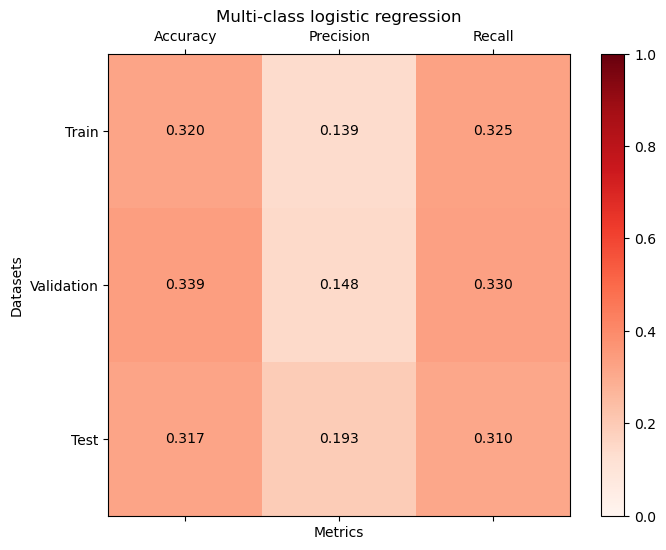

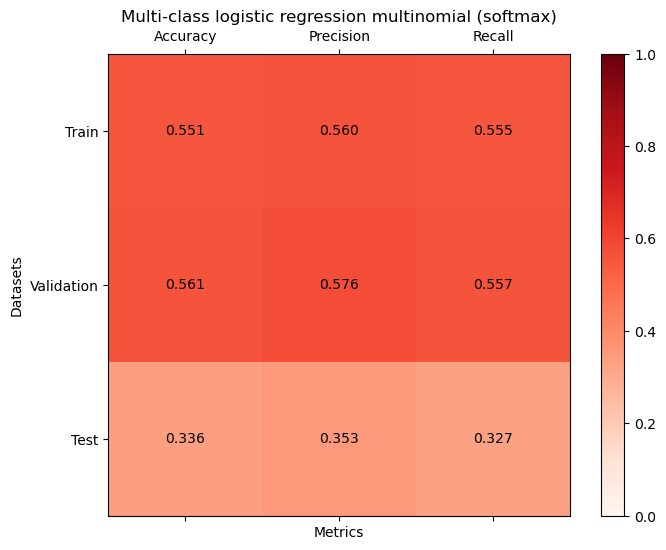

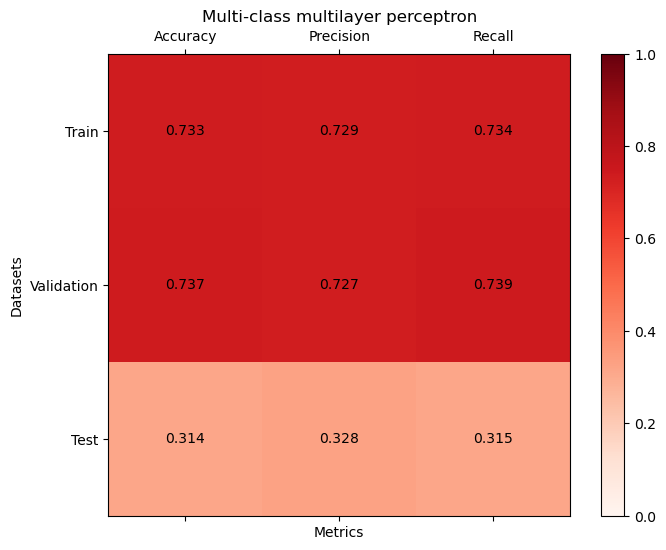

In [30]:
# mlp_multi
# multi_log_reg_multinomial
# multi_log_reg

import numpy as np

def precision_recall_multi(y_true, y_pred, num_classes):
    precision = np.zeros(num_classes)
    recall = np.zeros(num_classes)
    
    for i in range(num_classes):
        # True Positives (TP): Predicted as class 'i' and actual is class 'i'
        TP = np.sum((y_pred == i) & (y_true == i))
        
        # False Positives (FP): Predicted as class 'i' but actual is not class 'i'
        FP = np.sum((y_pred == i) & (y_true != i))
        
        # False Negatives (FN): Predicted as not class 'i' but actual is class 'i'
        FN = np.sum((y_pred != i) & (y_true == i))
        
        # Precision = TP / (TP + FP)
        precision[i] = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        
        # Recall = TP / (TP + FN)
        recall[i] = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return precision, recall

# Function to evaluate models
def evaluate_model(model, X, y, num_classes):
    predictions = model.predict(X)

    if hasattr(model, 'predict_proba'):  # For models that use probabilities
        predictions = np.argmax(predictions, axis=1)  # Get the predicted class from probabilities
    
    acc = np.mean(predictions == y)  # Accuracy
    precision, recall = precision_recall_multi(y, predictions, num_classes)  # Compute precision and recall for each class

    return acc, precision, recall

# linear_reg 
# logistic_reg 
# mlp

def plot_model(model, model_name):
    train_acc, train_prec, train_rec = evaluate_model(model, X_train_scaled, t_multi_train, n_classes)
    val_acc, val_prec, val_rec = evaluate_model(model, X_val_scaled, t_multi_val, n_classes)
    test_acc, test_prec, test_rec = evaluate_model(model, X_test, t_multi_test, n_classes)

    # Store results in a 3x3 matrix
    metrics = np.array([[train_acc, np.mean(train_prec), np.mean(train_rec)],
                        [val_acc, np.mean(val_prec), np.mean(val_rec)],
                        [test_acc, np.mean(test_prec), np.mean(test_rec)]])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plotting the 3x3 matrix as a heatmap with values as text
    cax = ax.matshow(metrics, cmap='Reds', vmin=0, vmax=1)

    # Add text labels to each cell
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{metrics[i, j]:.3f}', ha='center', va='center', color='black')

    # Adding axis labels and title
    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(["Accuracy", "Precision", "Recall"])
    ax.set_yticklabels(["Train", "Validation", "Test"])

    # Adding color bar for heatmap
    plt.colorbar(cax)

    # Set labels
    plt.xlabel("Metrics")
    plt.ylabel("Datasets")
    plt.title(model_name)

    # Show the plot
    plt.show()

plot_model(multi_log_reg, "Multi-class logistic regression")
plot_model(multi_log_reg_multinomial, "Multi-class logistic regression multinomial (softmax)")
plot_model(mlp_multi, "Multi-class multilayer perceptron")

# comment on the data
# similarly to binary classification models, the MLP-multilayerperceptron model performs the best on average across all the classes on the training data and the validation data
# however, they all suffer in the test data, which is also surprising how the softmax model slightly outperforms the MLP model
# What is a notable conclusion is how accurate these neural network models can be to predict a dataset that they've seen before
# similar to the binary classifiaction the MLP clearly outperforms on it's own training data and validation data

# obs: running the jupyther script multiple times might change the data/training accuracy, therefore keep in mind that i explain my own running of the observations

In [ ]:
# username: nikitafe, name: nikita